# Image Captioning with Hugging Face
This notebook uses the BLIP (Bootstrapping Language-Image Pre-training) model for automatic image captioning.

In [1]:
# Install required packages
!pip install transformers pillow torch torchvision accelerate

In [2]:
# Import libraries
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import requests
from io import BytesIO

In [3]:
# Set your Hugging Face token here
hf_token = "your_api_key"  # Replace with your actual token

# If you prefer to use authentication for private models
# from huggingface_hub import login
# login(token=hf_token)

In [4]:
# Load the model and processor
print("Loading BLIP model...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Model loaded on {device}")

Loading BLIP model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cuda


In [5]:
# Function to generate captions from image path or URL
def caption_image(image_input, conditional_text=None):
    """
    Generate caption for an image.

    Args:
        image_input: Either a file path (str) or URL (str) to the image
        conditional_text: Optional text to condition the caption generation

    Returns:
        Generated caption as string
    """
    # Load image
    if image_input.startswith('http://') or image_input.startswith('https://'):
        response = requests.get(image_input)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(image_input).convert('RGB')

    # Process image
    if conditional_text:
        # Conditional captioning
        inputs = processor(image, conditional_text, return_tensors="pt").to(device)
    else:
        # Unconditional captioning
        inputs = processor(image, return_tensors="pt").to(device)

    # Generate caption
    output = model.generate(**inputs, max_length=50)
    caption = processor.decode(output[0], skip_special_tokens=True)

    return caption

Caption: araffe view of a busy intersection with people walking and cars


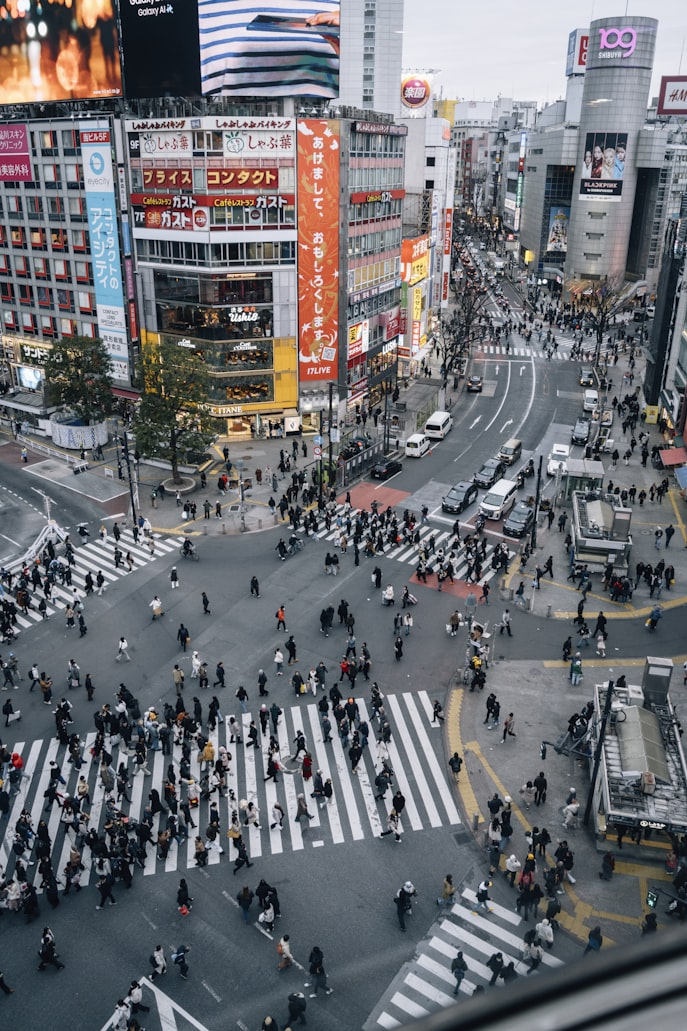

In [12]:
# Example 1: Caption an image from URL
image_url = "https://images.unsplash.com/photo-1771030669522-c7af247de300?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
caption = caption_image(image_url)
print(f"Caption: {caption}")

# Display the image
from IPython.display import display
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
display(img)

In [13]:
# Example 2: Caption a local image file
# Uncomment and modify the path below
# local_image_path = "path/to/your/image.jpg"
# caption = caption_image(local_image_path)
# print(f"Caption: {caption}")
# display(Image.open(local_image_path))

In [14]:
# Example 3: Conditional captioning (asking specific questions about the image)
image_url = "https://images.unsplash.com/photo-1771030669522-c7af247de300?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
question = "a photography of"  # You can customize this prompt
caption = caption_image(image_url, conditional_text=question)
print(f"Conditional Caption: {caption}")

Conditional Caption: a photography of a busy intersection with people crossing the street


In [18]:
# Batch captioning multiple images
def batch_caption_images(image_list):
    """
    Generate captions for multiple images.

    Args:
        image_list: List of image paths or URLs

    Returns:
        List of captions
    """
    captions = []
    for idx, img_path in enumerate(image_list):
        print(f"Processing image {idx+1}/{len(image_list)}...")
        caption = caption_image(img_path)
        captions.append(caption)
        print(f"  Caption: {caption}")
    return captions

# Example usage
image_urls = [
    "https://images.unsplash.com/photo-1771782191574-caf77b4522fe?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1676923901786-8e318b968758?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
]
captions = batch_caption_images(image_urls)

Processing image 1/2...
  Caption: a close up of a ring of light in the dark
Processing image 2/2...
  Caption: there are eggs, eggshells, and a flower on a table
